In [ ]:

import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import re
import numpy as np

In [215]:
data_dir = Path("../data")

# All 7 CSV files that share the 16-column schema
csv_files = [
    data_dir / "Core-Processors-1.8.csv",
    data_dir / "Xeon-Processors-1.8.csv",
    data_dir / "Atom-Processors-1.9-16col.csv",
    data_dir / "Celeron-Processors-1.9-16col.csv",
    data_dir / "Core_Ultra-Processors-1.10-16col.csv",
    data_dir / "Intel-Processors-1.9-16col.csv",
    data_dir / "Pentium-Processors-1.9-16col.csv",
]



In [216]:
def classify_suffix(name):
    # Extract trailing letters after the last number
    m = re.search(r'(\d+)([A-Z]+[0-9]?)$', name)
    suffix = m.group(2) if m else ""
    
    # Group into power tiers
    if suffix in ("K", "KF", "KS", "X", "XE", "HK", "HX"):
        return "High Perf"
    elif suffix in ("H", "HQ", "HL", "HE", "QM", "MQ"):
        return "High Perf Mobile"
    elif suffix in ("U", "UM", "UL", "UE"):
        return "Ultra-Low Power"
    elif suffix == "Y":
        return "Extreme Low Power"
    elif suffix in ("T", "TE"):
        return "Power Optimized"
    elif suffix in ("N", "NT", "NTE"):
        return "Low Power"
    elif suffix in ("E", "EQ", "EC"):
        return "Embedded"
    elif suffix in ("F", "KF"):
        return "No Graphics"
    elif suffix in ("M",):
        return "Mobile (Legacy)"
    elif suffix in ("S", "P", "G", "G1", "G4", "G7"):
        return "Standard / Graphics"
    elif suffix in ("B", "R", "RE", "RK"):
        return "BGA / Soldered"
    else:
        return "Standard"  # includes no suffix






In [217]:
gen_map = {
    "Merom": "Core 2", "Conroe": "Core 2", "Kentsfield": "Core 2",
    "Wolfdale": "Core 2", "Yorkfield": "Core 2", "Penryn": "Core 2",
    "Bloomfield": "Nehalem", "Lynnfield": "Nehalem", "Nehalem EP": "Nehalem",
    "Nehalem EX": "Nehalem", "Gulftown": "Westmere", "Clarkdale": "Westmere",
    "Arrandale": "Westmere", "Westmere EP": "Westmere", "Westmere EX": "Westmere",
    "Sandy Bridge": "Sandy Bridge", "Sandy Bridge E": "Sandy Bridge",
    "Sandy Bridge EN": "Sandy Bridge", "Sandy Bridge EP": "Sandy Bridge",
    "Ivy Bridge": "Ivy Bridge", "Ivy Bridge E": "Ivy Bridge",
    "Ivy Bridge EN": "Ivy Bridge", "Ivy Bridge EP": "Ivy Bridge",
    "Haswell": "Haswell", "Haswell E": "Haswell",
    "Broadwell": "Broadwell", "Broadwell E": "Broadwell",
    "Skylake": "Skylake", "Kaby Lake": "Kaby Lake",
    "Kaby Lake G": "Kaby Lake", "Kaby Lake R": "Kaby Lake",
    "Coffee Lake": "Coffee Lake", "Comet Lake": "Comet Lake",
    "Whiskey Lake": "Whiskey Lake", "Amber Lake": "Amber Lake",
    "Amber Lake Y": "Amber Lake", "Ice Lake": "Ice Lake",
    "Tiger Lake": "Tiger Lake", "Rocket Lake": "Rocket Lake",
    "Alder Lake": "Alder Lake", "Alder Lake-N": "Alder Lake",
    "Raptor Lake": "Raptor Lake", "Meteor Lake": "Meteor Lake",
    "Lunar Lake": "Lunar Lake", "Arrow Lake": "Arrow Lake",
    "Panther Lake": "Panther Lake",
    "Sapphire Rapids": "Xeon Scalable", "Sapphire Rapids HBM": "Xeon Scalable",
    "Sapphire Rapids Edge Enhanced": "Xeon Scalable",
    "Emerald Rapids": "Xeon Scalable", "Cascade Lake": "Xeon Scalable",
    "Cooper Lake": "Xeon Scalable", "Denverton": "Atom",
    "Rangeley": "Atom", "Avoton": "Atom", "Centerton": "Atom",
    "Braswell": "Atom", "Cherry Trail": "Atom",
    "Bay Trail": "Atom", "Merrifield": "Atom",
    "Moorefield": "Atom", "Jasper Lake": "Atom",
    "Elkhart Lake": "Atom", "Amston Lake": "Atom",
    "Cloverview": "Atom", "Cedarview": "Atom",
    "Penwell": "Atom", "SoFIA 3G R": "Atom", "SoFIA LTE": "Atom",
    "Twin Lake": "Atom", "Gemini Lake": "Atom",
    "Gemini Lake Refresh": "Atom", "Snow Ridge": "Atom",
    "Parker Ridge": "Atom", "Hewitt Lake": "Atom",
    "Lakefield": "Hybrid", "Jasper Forest": "Xeon Legacy",
    "Nocona": "Xeon Legacy", "Prestonia": "Xeon Legacy",
    "Sossaman": "Xeon Legacy", "Tigerton": "Xeon Legacy",
    "Dunnington": "Xeon Legacy", "Clovertown": "Xeon Legacy",
    "Harpertown": "Xeon Legacy", "Woodcrest": "Xeon Legacy",
    "Gladden": "Xeon Legacy", "Crystal Well": "Haswell",
    "Devil's Canyon": "Haswell",
}

arch_features = {
 # Family: [L2_per_P_Core_KB, Is_Tiled, Is_Mesh, Est_Node_Density_MTr_mm2]

 # --- Core 2 (Penryn flagship, 45nm, monolithic, ring) ---
 # L2 was large shared slabs; per-core equiv for Penryn ≈ 3072 KB (6MB/2 cores)
 "Core 2": [3072, 0, 0, 4.0],

 # --- Nehalem (45nm, Bloomfield/Lynnfield, ring) ---
 "Nehalem": [256, 0, 0, 4.0],

 # --- Westmere (32nm shrink of Nehalem, ring) ---
 "Westmere": [256, 0, 0, 9.0],

 # --- Sandy Bridge (32nm, ring bus introduced) ---
 "Sandy Bridge": [256, 0, 0, 9.0],

 # --- Ivy Bridge (22nm shrink of Sandy Bridge, ring) ---
 "Ivy Bridge": [256, 0, 0, 17.0],

 # --- Haswell (22nm, ring) ---
 "Haswell": [256, 0, 0, 17.0],

 # --- Broadwell (14nm first gen, ring) ---
 "Broadwell": [256, 0, 0, 37.5],

 # --- Skylake (14nm, ring, consumer) ---
 "Skylake": [256, 0, 0, 37.5],

 # --- Kaby Lake (14nm+, minor refresh, ring) ---
 "Kaby Lake": [256, 0, 0, 37.5],

 # --- Coffee Lake (14nm++, ring) ---
 "Coffee Lake": [256, 0, 0, 37.5],

 # --- Comet Lake (14nm+++, Skylake-derived, ring) ---
 "Comet Lake": [256, 0, 0, 37.5],

 # --- Whiskey Lake (14nm++, U-series mobile Skylake deriv., ring) ---
 "Whiskey Lake": [256, 0, 0, 37.5],

 # --- Amber Lake (14nm++, Y-series ultra-low power, ring) ---
 "Amber Lake": [256, 0, 0, 37.5],

 # --- Ice Lake (Intel 10nm / ~10SF, new Sunny Cove core, ring on client) ---
 # L2 = 512 KB per core (Sunny Cove)
 "Ice Lake": [512, 0, 0, 63.0],

 # --- Tiger Lake (Intel SuperFin 10nm+, Willow Cove core, ring) ---
 # L2 = 1280 KB per core (Willow Cove)
 "Tiger Lake": [1280, 0, 0, 63.0],

 # --- Rocket Lake (14nm backport of Cypress Cove / Ice Lake arch, ring) ---
 # L2 = 512 KB (same Cypress Cove = ported Sunny Cove)
 "Rocket Lake": [512, 0, 0, 37.5],

 # --- Alder Lake (Intel 7 / 10nm ESF, hybrid P+E, ring, monolithic) ---
 # P-Core (Golden Cove) L2 = 1280 KB
 "Alder Lake": [1280, 0, 0, 100.0],

 # --- Raptor Lake (Intel 7, refined Alder, hybrid, ring, monolithic) ---
 # P-Core (Raptor Cove) L2 = 2048 KB
 "Raptor Lake": [2048, 0, 0, 100.0],

 # --- Meteor Lake (Intel 4 compute tile + Foveros, hybrid, tiled) ---
 # P-Core (Redwood Cove) L2 = 2048 KB; compute tile on Intel 4
 "Meteor Lake": [2048, 1, 0, 100.0], # Intel 4 ≈ same density as Intel 7 per ARK; compute tile ~100 MTr/mm²

 # --- Lunar Lake (Intel 18A class / TSMC N3B for compute tile, Foveros) ---
 # P-Core (Lion Cove) L2 = 2048 KB; TSMC N3B ≈ 170 MTr/mm² (est., widely cited)
 "Lunar Lake": [2560, 1, 0, 170.0], # TSMC N3B consensus density estimate

 # --- Arrow Lake (TSMC N3B compute tile, Foveros, hybrid) ---
 # P-Core (Lion Cove) L2 = 2048 KB
 "Arrow Lake": [3072, 1, 0, 170.0], # TSMC N3B, same tile node as Lunar Lake

 # --- Panther Lake (Intel 18A, Foveros, hybrid — 2025 est.) ---
 # P-Core L2 expected ~2048 KB; Intel 18A density ≈ 150 MTr/mm² (engineering consensus, unconfirmed)
 "Panther Lake": [3072, 1, 0, 150.0], # ESTIMATE: Intel 18A ~150 MTr/mm², subject to revision

 # --- Xeon Scalable (Skylake-SP through Sapphire Rapids; Mesh; flagship = SPR on Intel 7, tiled) ---
 # Flagship Sapphire Rapids: Ice Lake-SP P-core L2=1024KB; SPR uses HBM tiles (tiled=1)
 # Using Ice Lake-SP as primary server flagship era (ICELAKE-SP L2=1024KB, mesh, monolithic=0... but SPR=1)
 # Compromise: use SPR as the "Xeon Scalable" representative (tiled=1, mesh=1, Intel 7 node)
 # P-core L2 for SPR = 2048 KB (Golden Cove server); Intel 7 ≈ 100 MTr/mm²
 "Xeon Scalable": [2048, 1, 1, 100.0],

 # --- Atom (representing Gracemont / Alder Lake E-core as flagship small-core line) ---
 # Gracemont L2 = 2 MB / 4 cores = 512 KB per core; Intel 7; monolithic tile; ring
 "Atom": [512, 0, 0, 100.0],

 # --- Hybrid (Lakefield as first hybrid; Foveros tiled; Sunny Cove P-core L2=512KB; 10nm) ---
 # Lakefield = first Foveros consumer product; P-core = Sunny Cove (512 KB L2); 10nm SuperFin
 "Hybrid": [512, 1, 0, 63.0],

 # --- Xeon Legacy (pre-Skylake-SP server; Sandy Bridge-EP / Ivy Bridge-EP / Haswell-EP flagship) ---
 # Representative: Haswell-EP (most prominent pre-mesh Xeon); 256 KB L2; 22nm; ring; monolithic
 "Xeon Legacy": [256, 0, 0, 17.0],
}



In [253]:
# Read each file and collect the DataFrames
frames = []
for f in csv_files:
    print(f"Loading {f.name} ...")
    df = pd.read_csv(f)
    family = f.stem.split("-")[0]
    # "Core-Processors-1.8" → "Core"
    # "Core-Ultra-Processors-1.10" → "Core-Ultra"
    df["Vertical Segment"] = family
    frames.append(df)



family_map = {
    "Atom": "Atom", "Celeron": "Celeron", "Core": "Core",
    "CoreUltra": "Core Ultra", "Intel": "Intel",
    "Pentium": "Pentium", "Xeon": "Xeon"
}




df = pd.concat(frames, ignore_index=True)
df["Release Date"] = df["Release Date"].str[-2:].astype(int) + 2000
df["Power Tier"] = df["Product"].apply(classify_suffix)
df["Arch Group"] = df["Code Name"].map(gen_map)

df["L2_per_Core_KB"] = df["Arch Group"].map(lambda g: arch_features[g][0] if g in arch_features else None)
df["Is_Tiled"]       = df["Arch Group"].map(lambda g: arch_features[g][1] if g in arch_features else None)
df["Is_Mesh"]        = df["Arch Group"].map(lambda g: arch_features[g][2] if g in arch_features else None)
df["Node_Density"]   = df["Arch Group"].map(lambda g: arch_features[g][3] if g in arch_features else None)
df['Log_Node_Density'] = np.log1p(df['Node_Density'])
df = df.drop(columns=['Node_Density'])
df['Cores_x_Is_Mesh'] = df['Cores'] * df['Is_Mesh']
df['TDP_x_Is_Tiled'] = df['TDP(W)'] * df['Is_Tiled']
df['Density_x_ReleaseYear'] = df['Log_Node_Density'] * df['Release Date']

print(df["Power Tier"].value_counts())


print(df.dtypes)


Loading Core-Processors-1.8.csv ...
Loading Xeon-Processors-1.8.csv ...
Loading Atom-Processors-1.9-16col.csv ...
Loading Celeron-Processors-1.9-16col.csv ...
Loading Core_Ultra-Processors-1.10-16col.csv ...
Loading Intel-Processors-1.9-16col.csv ...
Loading Pentium-Processors-1.9-16col.csv ...
Power Tier
Standard               1418
Ultra-Low Power         222
Power Optimized         190
High Perf Mobile        178
High Perf               122
Standard / Graphics     102
Mobile (Legacy)          88
Embedded                 81
Low Power                65
Extreme Low Power        56
BGA / Soldered           50
No Graphics              35
Name: count, dtype: int64
Product                      str
Status                       str
Release Date               int64
Code Name                    str
Cores                      int64
Threads                  float64
Lithography(nm)          float64
Max. Turbo Freq.(GHz)    float64
Base Freq.(GHz)          float64
TDP(W)                   float64
C

In [250]:
df.sample()

,Product,Status,Release Date,Code Name,Cores,Threads,Lithography(nm),Max. Turbo Freq.(GHz),Base Freq.(GHz),TDP(W),...,Memory Types,Max Memory Speed(MHz),Integrated Graphics,Vertical Segment,Power Tier,Arch Group,L2_per_Core_KB,Is_Tiled,Is_Mesh,Log_Node_Density
187,Core i5-12600HL,Launched,2022,Alder Lake,12,16.0,7.0,4.5,2.7,45.0,...,"Up to DDR5 4800 MT/s, Up to DDR4 3200 MT/s",NaN,Intel Iris Xe Graphics,Core,High Perf Mobile,Alder Lake,1280.0,0.0,0.0,4.615121


In [254]:


featuresToClean  = ["Lithography(nm)", "Cores", "TDP(W)", "Release Date", "Max. Turbo Freq.(GHz)", "Threads", "L2_per_Core_KB", "Is_Tiled", "Is_Mesh", "Log_Node_Density", "Cores_x_Is_Mesh", "TDP_x_Is_Tiled", "Density_x_ReleaseYear"]

# Only convert the columns we actually need 
cols_to_clean = featuresToClean
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=cols_to_clean, inplace=True)
print(f"Samples after cleaning: {len(df)}")

Samples after cleaning: 1829


In [255]:
family_dummies = pd.get_dummies(df["Vertical Segment"], prefix="fam", drop_first=True)
tier_dummies = pd.get_dummies(df["Power Tier"], prefix="tier", drop_first=True)


X = pd.concat([
    df[["Lithography(nm)", "Cores", "TDP(W)", "Release Date", "Threads", "L2_per_Core_KB", "Is_Tiled", "Is_Mesh", "Log_Node_Density", "Cores_x_Is_Mesh", "TDP_x_Is_Tiled", "Density_x_ReleaseYear"]],
    family_dummies,
    tier_dummies
], axis=1)
y = df["Max. Turbo Freq.(GHz)"]


print(f"Clean samples: {len(df)}")
X.sample()


Clean samples: 1829


,Lithography(nm),Cores,TDP(W),Release Date,Threads,L2_per_Core_KB,Is_Tiled,Is_Mesh,Log_Node_Density,Cores_x_Is_Mesh,...,tier_Extreme Low Power,tier_High Perf,tier_High Perf Mobile,tier_Low Power,tier_Mobile (Legacy),tier_No Graphics,tier_Power Optimized,tier_Standard,tier_Standard / Graphics,tier_Ultra-Low Power
1897,14.0,4,35.0,2015,8.0,256.0,0.0,0.0,3.650658,0.0,...,False,False,False,False,False,False,False,True,False,False


In [256]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



In [ ]:
model = ridge(alpha=1.0)
model.fit(X_train, y_train)


NameError: name 'Ridge' is not defined

In [258]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)


In [259]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


print("Training set:")
print(f"  R²   = {r2_score(y_train, y_pred_train):.4f}")
print(f"  MAE  = {mean_absolute_error(y_train, y_pred_train):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_train, y_pred_train):.4f} GHz")

print("\nTest set:")
print(f"  R²   = {r2_score(y_test, y_pred_test):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_test):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_test, y_pred_test):.4f} GHz")



Training set:
  R²   = 0.7032
  MAE  = 0.3538 GHz
  RMSE = 0.4515 GHz

Test set:
  R²   = 0.6851
  MAE  = 0.3680 GHz
  RMSE = 0.4765 GHz


In [229]:
# 1. Grab the exact column names from your X DataFrame before it was scaled
feature_names = X.columns

# 2. Grab the weights (if using LinearRegression, model.coef_ is a flat array)
weights = model.coef_

# 3. Combine them safely
weight_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
}).sort_values(by='Weight', ascending=False)

print(weight_df)

                     Feature        Weight
3               Release Date  7.354789e-01
10                  fam_Core  5.029722e-01
14                  fam_Xeon  3.682784e-01
2                     TDP(W)  2.942210e-01
1                      Cores  2.118916e-01
5             L2_per_Core_KB  1.758427e-01
11            fam_Core_Ultra  1.586097e-01
0            Lithography(nm)  1.012369e-01
17            tier_High Perf  8.051961e-02
24  tier_Standard / Graphics  6.129249e-02
20      tier_Mobile (Legacy)  3.662644e-02
18     tier_High Perf Mobile  3.483464e-02
6                   Is_Tiled  2.370289e-02
13               fam_Pentium  1.864863e-02
21          tier_No Graphics  1.353475e-02
12                 fam_Intel  4.684525e-03
15             tier_Embedded  2.249110e-03
9                fam_Celeron  6.938894e-16
23             tier_Standard -1.204686e-02
25      tier_Ultra-Low Power -1.782401e-02
22      tier_Power Optimized -2.284083e-02
16    tier_Extreme Low Power -7.235531e-02
7          

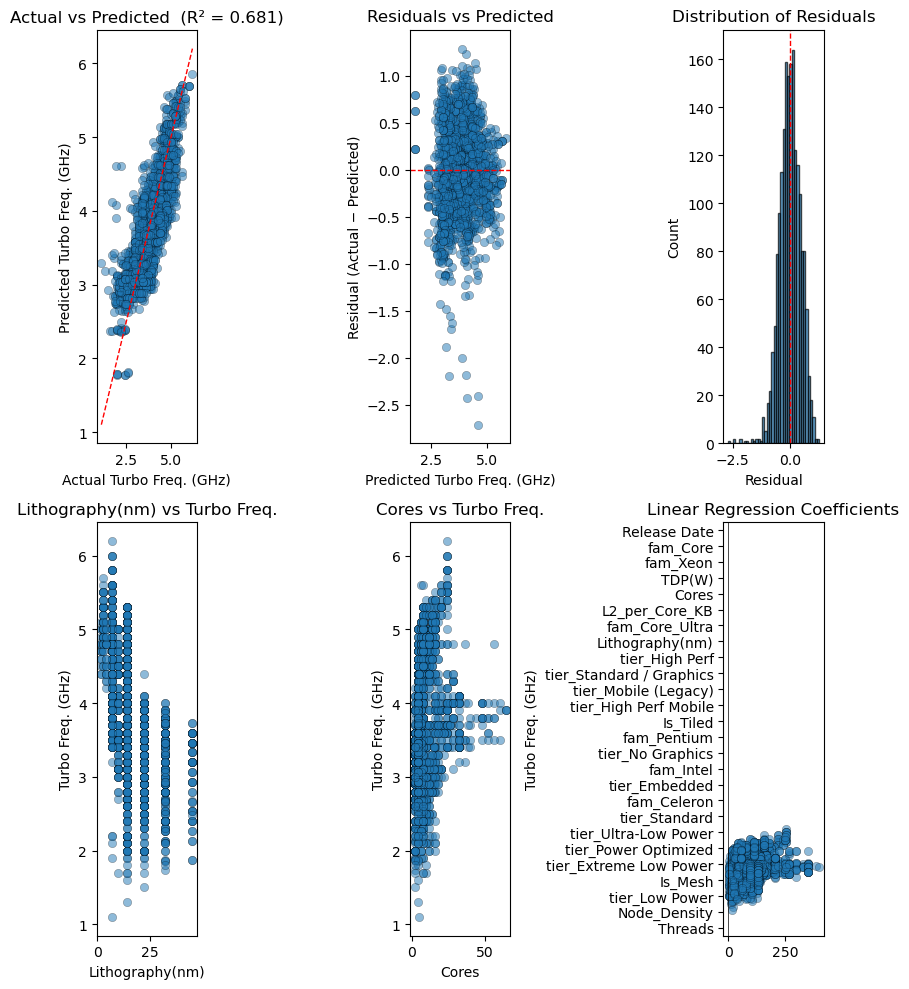

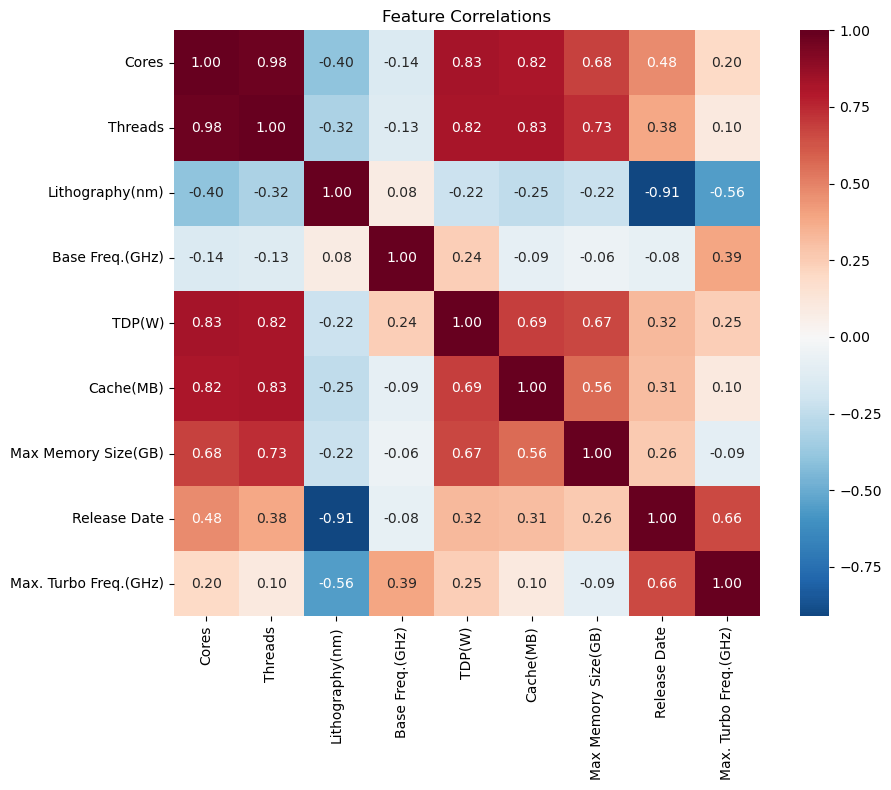

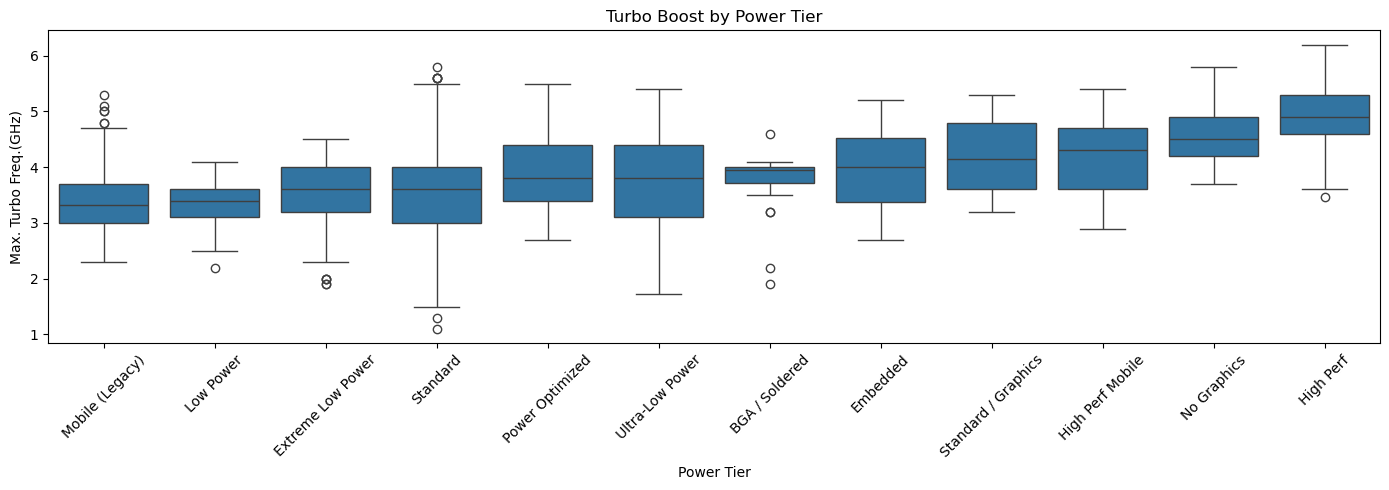

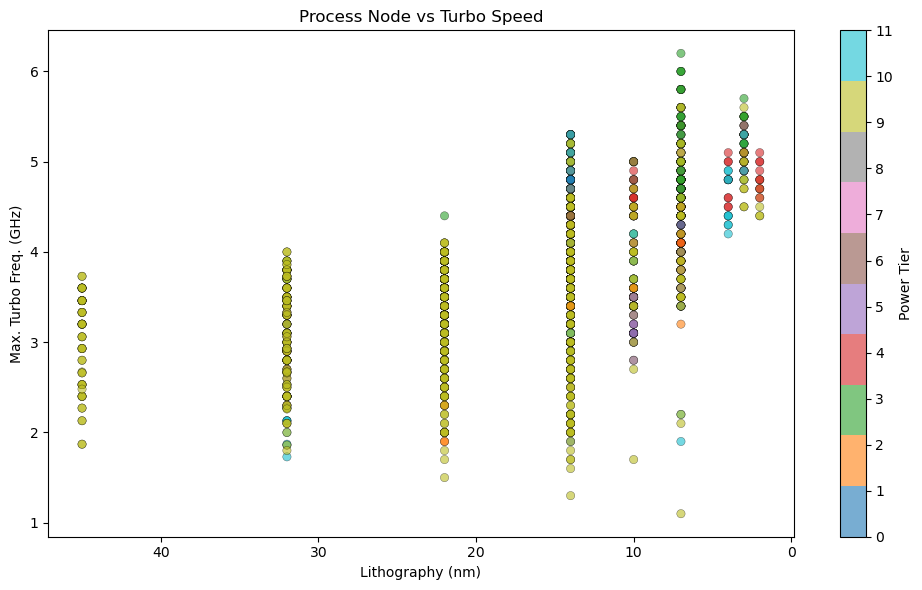

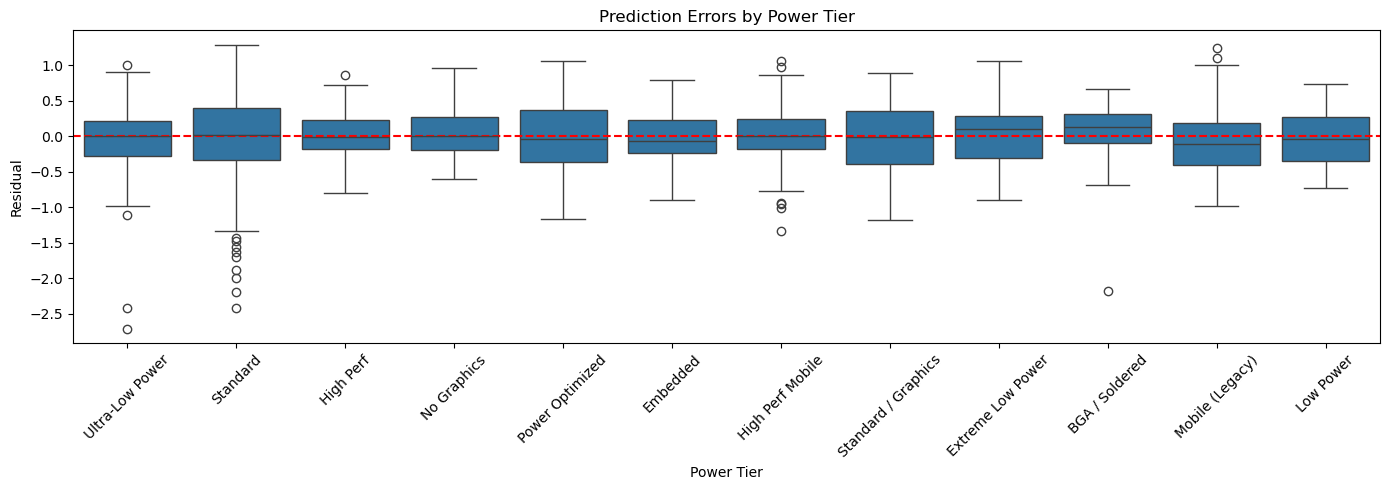

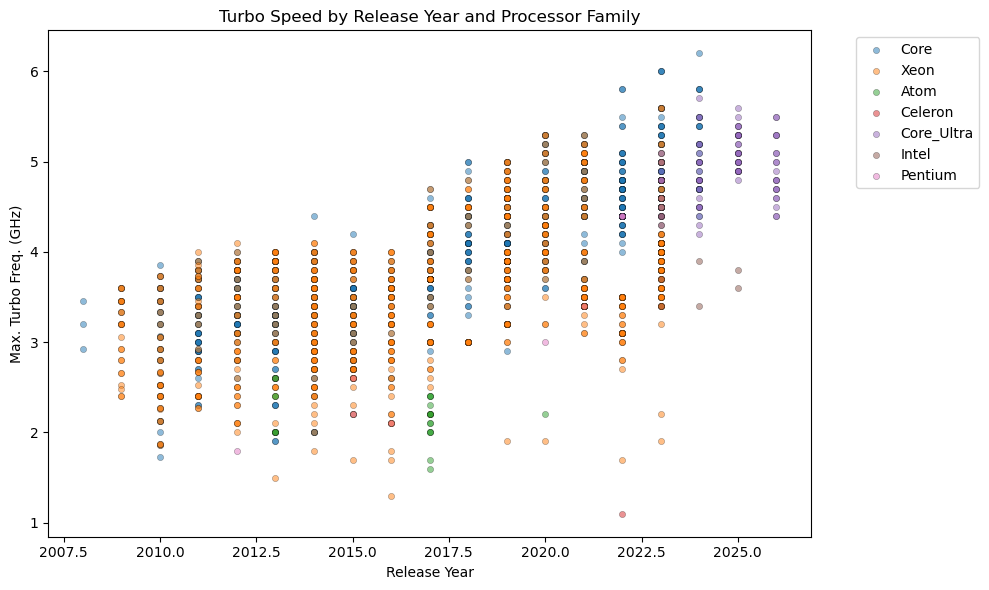

<Figure size 640x480 with 0 Axes>

In [246]:
import matplotlib.pyplot as plt

# ── Predict ──────────────────────────────────────────────────
y_pred = model.predict(X_scaled)
residuals = y - y_pred

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1 ── Actual vs Predicted ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y, y_pred, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual Turbo Freq. (GHz)")
ax.set_ylabel("Predicted Turbo Freq. (GHz)")
ax.set_title(f"Actual vs Predicted  (R² = {r2_score(y, y_pred):.3f})")

# 2 ── Residuals vs Predicted ─────────────────────────────────
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.axhline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted Turbo Freq. (GHz)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs Predicted")

# 3 ── Histogram of Residuals ─────────────────────────────────
ax = axes[0, 2]
ax.hist(residuals, bins=40, edgecolor="k", alpha=0.7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Distribution of Residuals")

# 4, 5, 6 ── Feature vs Target ────────────────────────────────
features = ["Lithography(nm)", "Cores", "TDP(W)"]
for i, (feat, ax) in enumerate(zip(features, [axes[1, 0], axes[1, 1], axes[1, 2]])):
    ax.scatter(X[feat], y, alpha=0.5, edgecolors="k", linewidth=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel("Turbo Freq. (GHz)")
    ax.set_title(f"{feat} vs Turbo Freq.")

coef_series = pd.Series(model.coef_, index=X.columns)
coef_series.sort_values().plot(kind="barh", figsize=(8, 10))
plt.axvline(0, color="k", linewidth=0.5)
plt.title("Linear Regression Coefficients")
plt.tight_layout()

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["Cores", "Threads", "Lithography(nm)", "Base Freq.(GHz)",
            "TDP(W)", "Cache(MB)", "Max Memory Size(GB)", "Release Date",
            "Max. Turbo Freq.(GHz)"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="RdBu_r", center=0,
            fmt=".2f", square=True)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
order = df.groupby("Power Tier")["Max. Turbo Freq.(GHz)"].median().sort_values().index
sns.boxplot(data=df, x="Power Tier", y="Max. Turbo Freq.(GHz)", order=order)
plt.xticks(rotation=45)
plt.title("Turbo Boost by Power Tier")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["Lithography(nm)"], df["Max. Turbo Freq.(GHz)"],
                      c=pd.Categorical(df["Power Tier"]).codes, cmap="tab10",
                      alpha=0.6, edgecolors="k", linewidth=0.3)
plt.colorbar(scatter, ticks=range(12), label="Power Tier")
plt.xlabel("Lithography (nm)")
plt.ylabel("Max. Turbo Freq. (GHz)")
plt.title("Process Node vs Turbo Speed")
plt.gca().invert_xaxis()  # smaller nm = newer = should be faster
plt.tight_layout()
plt.show()

residual_df = pd.DataFrame({"Power Tier": df["Power Tier"], "Residual": residuals})
plt.figure(figsize=(14, 5))
sns.boxplot(data=residual_df, x="Power Tier", y="Residual")
plt.axhline(0, color="r", linestyle="--")
plt.xticks(rotation=45)
plt.title("Prediction Errors by Power Tier")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
families = df["Vertical Segment"].unique()
colors = plt.cm.tab10(range(len(families)))
for fam, color in zip(families, colors):
    mask = df["Vertical Segment"] == fam
    plt.scatter(df.loc[mask, "Release Date"], df.loc[mask, "Max. Turbo Freq.(GHz)"],
                label=fam, alpha=0.5, color=color, edgecolors="k", linewidth=0.3, s=20)
plt.xlabel("Release Year")
plt.ylabel("Max. Turbo Freq. (GHz)")
plt.title("Turbo Speed by Release Year and Processor Family")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

In [231]:
# No